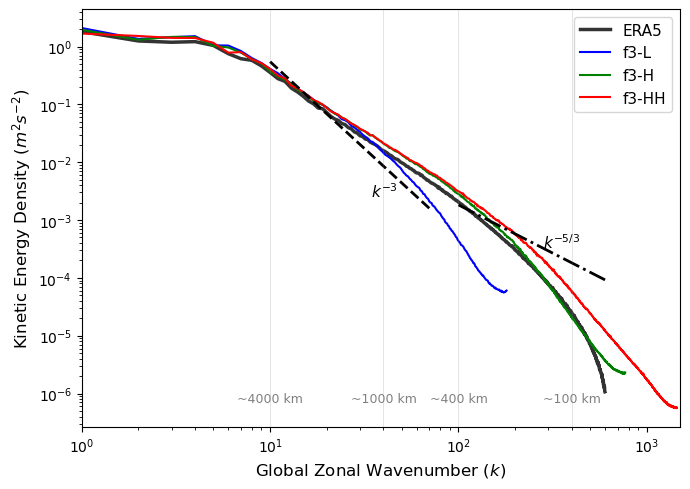

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD PRECOMPUTED DATA DUE TO LARGE FILE SIZE TO UPLOAD
# ============================================================

ds = xr.open_dataset("../Data/KE/ke_spectrum_summary.nc")

# Extract exactly like original variables
k_L = ds["k_L"].values
spec_L = ds["ke_L"].values

k_H = ds["k_H"].values
spec_H = ds["ke_H"].values

k_HH = ds["k_HH"].values
spec_HH = ds["ke_HH"].values

k_ERA = ds["k_ERA"].values
spec_ERA = ds["ke_ERA"].values


# ============================================================
# ORIGINAL PLOTTING CODE <<<
# (UNCHANGED)
# ============================================================

fig, ax1 = plt.subplots(figsize=(7, 5))

# Plot spectra
if k_ERA is not None:
    limit_ERA = 600
    ax1.loglog(k_ERA[1:limit_ERA], spec_ERA[1:limit_ERA],
               'k-', lw=2.5, alpha=0.8, label='ERA5')

if k_L is not None:
    ax1.loglog(k_L[1:], spec_L[1:], 'b-', lw=1.5, label='f3-L')

if k_H is not None:
    ax1.loglog(k_H[1:], spec_H[1:], 'g-', lw=1.5, label='f3-H')

if k_HH is not None:
    ax1.loglog(k_HH[1:], spec_HH[1:], 'r-', lw=1.5, label='f3-HH')


# --- Reference slopes ---
ref_data = spec_HH if k_HH is not None else spec_ERA
ref_k = k_HH if k_HH is not None else k_ERA

k_range3 = np.linspace(10, 70, 50)
idx_ref = 15
y3 = ref_data[idx_ref] * (k_range3 / ref_k[idx_ref])**-3
ax1.loglog(k_range3, y3, 'k--', lw=2)

# k^-5/3
k_range53 = np.linspace(100, 600, 50)
idx_tail = 200
y53 = ref_data[idx_tail] * (k_range53 / ref_k[idx_tail])**(-5/3)
ax1.loglog(k_range53, y53, 'k-.', lw=2)


# --- Axis formatting ---
ax1.set_xlabel("Global Zonal Wavenumber ($k$)", fontsize=12)
ax1.set_ylabel("Kinetic Energy Density ($m^2 s^{-2}$)", fontsize=12)
ax1.set_xlim(1, 1500)
ax1.legend(fontsize=11)
ax1.grid(True, which="both", ls="-", axis='x', alpha=0.0)


# --- Annotate slopes at midpoint ---
mid3 = len(k_range3)//2
ax1.text(k_range3[mid3], y3[mid3]*0.3, r'$k^{-3}$',
        fontsize=11, rotation=-0, ha='center')

mid53 = len(k_range53)//2
ax1.text(k_range53[mid53], y53[mid53]*1.5, r'$k^{-5/3}$',
        fontsize=11, rotation=-0, ha='center')


# --- Clean wavelength annotations (NO secondary axis) -------------
wavelengths = [4000, 1000, 400, 100]  # km
k_positions = [40000/w for w in wavelengths]

for kpos, wl in zip(k_positions, wavelengths):
    ax1.axvline(kpos, color='gray', lw=0.5, alpha=0.3)
    ax1.text(kpos, ax1.get_ylim()[0]*4,
            f'~{wl} km',
            rotation=0,
            va='top',
            ha='center',
            fontsize=9,
            color='gray')
####################################################################

plt.tight_layout()
plt.savefig('../Figure/11_KE_spectrum_from_saved.pdf', dpi=300)
plt.show()